<div dir="rtl">

# DBSCAN بخش ۴: Grid Search و مدل نهایی

در این نوت‌بوک eps و min_samples ر, با هم تغییر می‌دهیم. نوت‌بوک ۳ نشان داد با تغییر فقط یکی به ۳ خوشه نمی‌رسیم چون اثر این دو به هم وابستست.
داده مثل نوت‌بوک‌های قبلی آماده شده و همان نمونه ۵۰ هزارتایی گرفته شده.

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
df = pd.read_parquet("../data/Divar_cleaned.parquet")

is_sell = df["cat2_slug"].str.contains("sell", na=False).fillna(False).astype(bool)
is_full_credit = (df["inferred_full_credit"] == True).fillna(False).astype(bool)

df["unified_price"] = np.select(
    [is_sell, is_full_credit],
    [df["price_value"], df["transformable_credit"]],
    default=df["transformed_credit"],
)
df["unified_price"] = df["unified_price"].replace(0, np.nan)

features = ["location_utm_x", "location_utm_y", "unified_price"]
data = df[features + ["city_slug", "cat2_slug"]].dropna(subset=features).copy()

def is_fake_price(price):
    digits = str(int(price))
    return len(digits) >= 6 and len(set(digits)) == 1

data = data[~data["unified_price"].apply(is_fake_price)]
data["log_price"] = np.log1p(data["unified_price"])
low, high = data["log_price"].quantile([0.01, 0.99])
data = data[data["log_price"].between(low, high)].copy()

X_scaled = StandardScaler().fit_transform(data[["location_utm_x", "location_utm_y", "log_price"]])

rng = np.random.RandomState(42)
pos = rng.choice(len(data), 50_000, replace=False)
sample = data.iloc[pos].copy()
X_sample = X_scaled[pos]

big_limit = int(len(sample) * 0.01)
print(f"dade tamiz: {len(data):,} | nemoone: {len(sample):,}")

dade tamiz: 425,471 | nemoone: 50,000


<div dir="rtl">

## ۲. Grid Search

۹ مقدار eps و ۷ مقدار min_samples یعنی ۶۳ ترکیب رو امتحان کردیم. بازه‌ها از نتیجه نوت‌بوک‌های ۲ و ۳ انتخاب شده‌اند و اطراف ۰.۲۷ تا ۰.۲۸ ریزتر هستند. برای هر ترکیب تعداد کل خوشه‌ها و خوشه‌های معنادار و تعداد و درصد Noiseثبت شد خوشه‌ای رو معنادار حساب کردیم که حداقل ۱ درصد نمونه رو داشته باشه تو خودش  

</div>

In [2]:
eps_values = [0.15, 0.2, 0.25, 0.27, 0.275, 0.28, 0.3, 0.35, 0.4]
ms_values = [5, 10, 15, 20, 30, 40, 50]
rows = []
for eps in eps_values:
    for ms in ms_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_sample)
        sizes = pd.Series(labels[labels != -1]).value_counts()
        noise = (labels == -1).sum()
        big = sizes[sizes >= big_limit]

        rows.append({
            "eps": eps,
            "min_samples": ms,
            "clusters": len(sizes),
            "big_clusters": len(big),
            "big_sizes_%": list((big / len(sample) * 100).round(1)),
            "noise_count": noise,
            "noise_percent": round(noise / len(sample) * 100, 2),
        })
    print(f"eps={eps} anjam shod")

grid = pd.DataFrame(rows)
grid

eps=0.15 anjam shod
eps=0.2 anjam shod
eps=0.25 anjam shod
eps=0.27 anjam shod
eps=0.275 anjam shod
eps=0.28 anjam shod
eps=0.3 anjam shod
eps=0.35 anjam shod
eps=0.4 anjam shod


,eps,min_samples,clusters,big_clusters,big_sizes_%,noise_count,noise_percent
0,0.15,5,149,8,"[63.9, 5.9, 4.9, 3.6, 3.2, 3.0, 1.6, 1.2]",1652,3.30
1,0.15,10,71,10,"[60.5, 5.9, 4.8, 3.2, 2.9, 1.9, 1.6, 1.4, 1.4,...",3217,6.43
2,0.15,15,51,10,"[60.1, 5.8, 4.8, 3.1, 2.8, 1.7, 1.5, 1.4, 1.3,...",4426,8.85
3,0.15,20,51,11,"[47.1, 11.3, 5.8, 4.7, 3.1, 2.8, 1.4, 1.4, 1.4...",5410,10.82
4,0.15,30,35,10,"[47.0, 11.0, 5.6, 4.6, 3.1, 2.6, 1.4, 1.3, 1.1...",7385,14.77
...,...,...,...,...,...,...,...
58,0.40,15,10,3,"[95.4, 1.1, 1.0]",442,0.88
59,0.40,20,11,2,"[95.3, 1.1]",530,1.06
60,0.40,30,9,2,"[95.0, 1.0]",844,1.69
61,0.40,40,7,2,"[94.7, 1.0]",1111,2.22


<div dir="rtl">

## ۳. نتیجه Grid Search

با بزرگ شدن eps Noise کم می‌شود و با بزرگ شدن min_samples زیاد می‌شود.
این دو هایپرپارامتر جای همدیگر رو می‌گیرن. مثلا ۳ خوشه هم با eps برابر ۰.۲ و min_samples برابر ۵ درمی‌آید و هم با eps برابر ۰.۲۷۵ و min_samples برابر ۲۰. یعنی اگر eps بزرگ شود برای حفظ همان ساختار min_samples هم باید بزرگ شود. هر دو در واقع یک چیز رو تعیین می‌کنن اونم اینه که   حداقل تراکمی که یک منطقه لازم داره تا خوشه حساب بشه


</div>

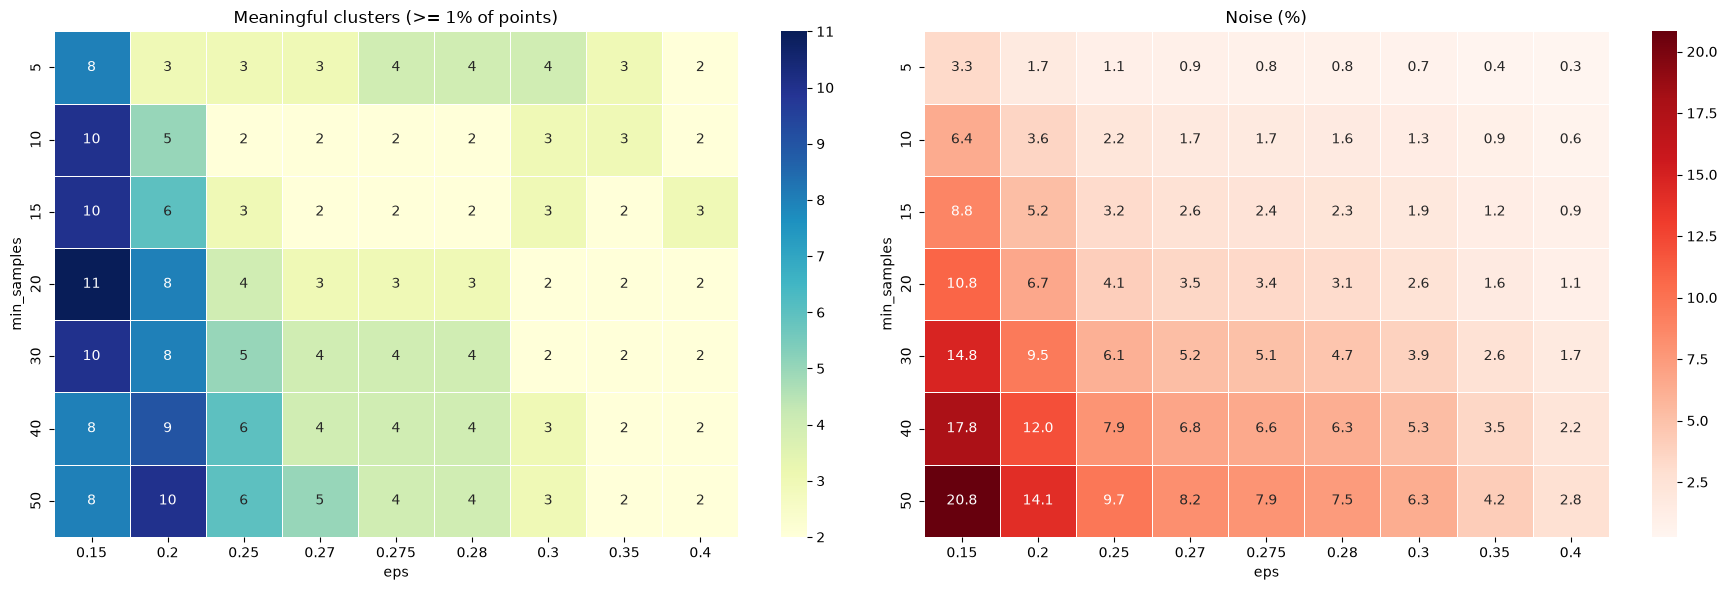

In [3]:
pivot_clusters = grid.pivot(index="min_samples", columns="eps", values="big_clusters")
pivot_noise = grid.pivot(index="min_samples", columns="eps", values="noise_percent")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_clusters, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0], linewidths=0.5)
axes[0].set_title("Meaningful clusters (>= 1% of points)")

sns.heatmap(pivot_noise, annot=True, fmt=".1f", cmap="Reds", ax=axes[1], linewidths=0.5)
axes[1].set_title("Noise (%)")

plt.tight_layout()
plt.show()

<div dir="rtl">

## ۴. انتخاب بهترین ترکیب

فقط ۳ خوشه داشتن کافی نیست. مثلا eps برابر ۰.۴ و min_samples برابر ۱۵ سه خوشه دارد ولی اندازه‌شان ۹۵ و ۱ و ۱ درصد است که عملا یک خوشه است. پس سه شرط گذاشتیم:
- دقیقا ۳ خوشه معنادار
- کوچک‌ترین خوشه حداقل ۵ درصد داده
- Noise حداکثر ۵ درصد

از بین ترکیب‌های قابل قبول بهترین رو با Silhouette Score انتخاب کردیم که همان معیار بخش K-means است. Silhouette فقط روی نقطه‌های سه خوشه اصلی حساب شده.

پنج ترکیب قابل قبول بودند و همه تقریبا یک جواب دادند یعنی سه خوشه ۸۰ و ۷ و ۶ درصدی با Silhouette بین ۰.۴۵۱ و ۰.۴۵۹. یعنی این ساختار به انتخاب دقیق هایپرپارامتر وابسته نیست.

eps برابر ۰.۲۷۵ و min_samples برابر ۲۰ رو انتخاب کردیم. اختلاف Silhouette آن با بالاترین فقط ۰.۰۰۴ است و وسط بازه پایدار است. با نتیجه مستقل نوت‌بوک‌های ۲ و ۳ هم یکی است.

</div>

In [4]:
from sklearn.metrics import silhouette_score
cands = grid[grid["big_clusters"] == 3].copy()
cands["largest_%"] = cands["big_sizes_%"].apply(lambda s: s[0])
cands["smallest_%"] = cands["big_sizes_%"].apply(lambda s: s[-1])

scores = []
for _, row in cands.iterrows():
    labels = DBSCAN(eps=row["eps"], min_samples=int(row["min_samples"])).fit_predict(X_sample)
    sizes = pd.Series(labels[labels != -1]).value_counts()
    big_ids = sizes[sizes >= big_limit].index
    idx = np.where(np.isin(labels, big_ids))[0]
    sub = np.random.RandomState(0).choice(idx, min(10_000, len(idx)), replace=False)
    scores.append(silhouette_score(X_sample[sub], labels[sub]))

cands["silhouette"] = np.round(scores, 3)
cands["qabel_ghabool"] = (cands["smallest_%"] >= 5) & (cands["noise_percent"] <= 5)

cands[["eps", "min_samples", "big_sizes_%", "noise_percent", "silhouette", "qabel_ghabool"]] \
    .sort_values(["qabel_ghabool", "silhouette"], ascending=False)

,eps,min_samples,big_sizes_%,noise_percent,silhouette,qabel_ghabool
24,0.270,20,"[79.7, 6.9, 6.0]",3.50,0.459,True
38,0.280,20,"[80.0, 7.0, 6.7]",3.12,0.459,True
31,0.275,20,"[79.9, 6.9, 6.0]",3.35,0.455,True
16,0.250,15,"[79.8, 7.0, 6.7]",3.21,0.453,True
7,0.200,5,"[80.0, 6.6, 6.0]",1.70,0.451,True
48,0.300,50,"[81.3, 6.0, 3.4]",6.33,0.480,False
47,0.300,40,"[81.9, 6.0, 4.0]",5.27,0.469,False
21,0.270,5,"[87.9, 6.8, 1.1]",0.86,0.437,False
44,0.300,15,"[87.7, 6.7, 1.0]",1.88,0.437,False
14,0.250,5,"[87.8, 6.8, 1.1]",1.05,0.432,False


<div dir="rtl">

## ۵. مدل نهایی

نمودار سوم فقط نقطه‌های Noise را نشان می‌دهد تا جدا از خوشه‌ها دیده شوند.

</div>

In [5]:
best_eps, best_ms = 0.275, 20
sample["cluster"] = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_sample)

sizes = sample.loc[sample["cluster"] != -1, "cluster"].value_counts()
big_ids = sizes[sizes >= big_limit].index

summary = sample[sample["cluster"].isin(big_ids)].groupby("cluster").agg(
    tedad=("cluster", "size"),
    median_gheymat=("unified_price", "median"),
    shahr_ha=("city_slug", lambda s: ", ".join(s.value_counts().head(4).index)),
    sahm_foroosh=("cat2_slug", lambda s: s.str.contains("sell").mean() * 100),
)
summary["darsad"] = (summary["tedad"] / len(sample) * 100).round(1)
summary["median_gheymat"] = (summary["median_gheymat"] / 1e9).round(2)
summary["sahm_foroosh"] = summary["sahm_foroosh"].round(1)

n_noise = (sample["cluster"] == -1).sum()
print(f"khoshe haye kol: {len(sizes)} | khoshe haye manadar: {len(big_ids)}")
print(f"noise: {n_noise:,} ({n_noise / len(sample) * 100:.2f}%)")
summary.sort_values("tedad", ascending=False)

khoshe haye kol: 15 | khoshe haye manadar: 3
noise: 1,674 (3.35%)


,tedad,median_gheymat,shahr_ha,sahm_foroosh,darsad
cluster,,,,,
0,39955,2.45,"tehran, karaj, isfahan, andisheh-new-town",80.0,79.9
1,3456,2.20,"shiraz, ahvaz, sadra, dezful",83.3,6.9
2,2999,2.20,"mashhad, neyshabur, golbahar-city, shandiz-city",82.0,6.0


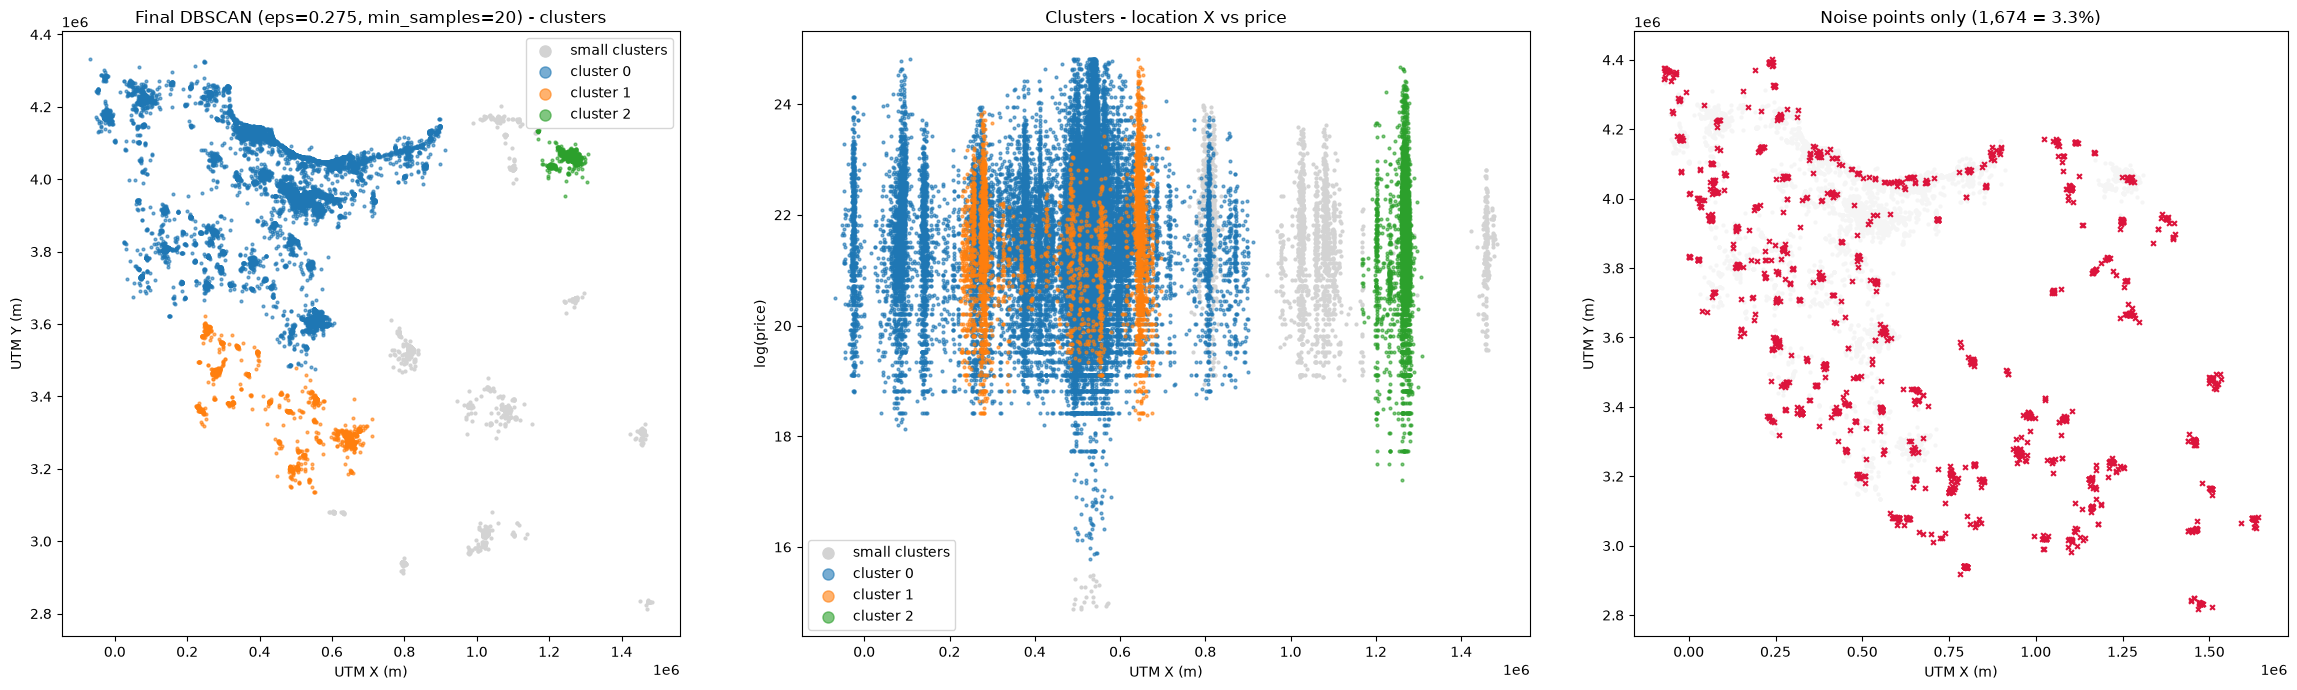

In [6]:
colors = dict(zip(sizes[big_ids].sort_values(ascending=False).index, ["tab:blue", "tab:orange", "tab:green"]))
big = sample[sample["cluster"].isin(big_ids)]
small = sample[~sample["cluster"].isin(big_ids) & (sample["cluster"] != -1)]
noise = sample[sample["cluster"] == -1]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, y_col, y_label in [(axes[0], "location_utm_y", "UTM Y (m)"), (axes[1], "log_price", "log(price)")]:
    ax.scatter(small["location_utm_x"], small[y_col], c="lightgray", s=4, label="small clusters")
    for cid, color in colors.items():
        part = big[big["cluster"] == cid]
        ax.scatter(part["location_utm_x"], part[y_col], c=color, s=4, alpha=0.6, label=f"cluster {cid}")
    ax.set_xlabel("UTM X (m)")
    ax.set_ylabel(y_label)
    ax.legend(markerscale=4)

axes[0].set_title(f"Final DBSCAN (eps={best_eps}, min_samples={best_ms}) - clusters")
axes[0].set_aspect("equal")
axes[1].set_title("Clusters - location X vs price")

axes[2].scatter(big["location_utm_x"], big["location_utm_y"], c="whitesmoke", s=4)
axes[2].scatter(noise["location_utm_x"], noise["location_utm_y"], c="crimson", marker="x", s=12)
axes[2].set_title(f"Noise points only ({len(noise):,} = {len(noise) / len(sample) * 100:.1f}%)")
axes[2].set_xlabel("UTM X (m)")
axes[2].set_ylabel("UTM Y (m)")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

<div dir="rtl">

## ۶. پایداری روی نمونه‌های دیگر

همه کارها روی یک نمونه بود. مدل نهایی را روی سه نمونه تصادفی دیگر هم اجرا کردیم تا ببینیم نتیجه به آن نمونه خاص وابسته نیست.

</div>

In [7]:
rows = []
for seed in [1, 7, 123]:
    p = np.random.RandomState(seed).choice(len(data), 50_000, replace=False)
    labels = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_scaled[p])
    part = data.iloc[p].assign(cluster=labels)
    sizes = pd.Series(labels[labels != -1]).value_counts()
    big = sizes[sizes >= big_limit]
    main_cities = [part.loc[part["cluster"] == cid, "city_slug"].value_counts().index[0] for cid in big.index]

    rows.append({
        "seed": seed,
        "big_clusters": len(big),
        "big_sizes_%": list((big / 50_000 * 100).round(1)),
        "shahr_asli_har_khoshe": main_cities,
        "noise_%": round((labels == -1).mean() * 100, 2),
    })

pd.DataFrame(rows)

,seed,big_clusters,big_sizes_%,shahr_asli_har_khoshe,noise_%
0,1,3,"[79.9, 7.1, 6.4]","[tehran, shiraz, mashhad]",3.14
1,7,2,"[86.8, 6.5]","[tehran, mashhad]",3.14
2,123,4,"[79.8, 7.0, 6.0, 1.0]","[tehran, shiraz, mashhad, kerman]",3.25
